<a href="https://colab.research.google.com/github/sap156/infinityskillshub/blob/main/Querying_Data_and_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generative AI for Data Professionals
# Data Querying, Analysis and Optimization — Module 4 Part 1
# Querying Data and Analysis

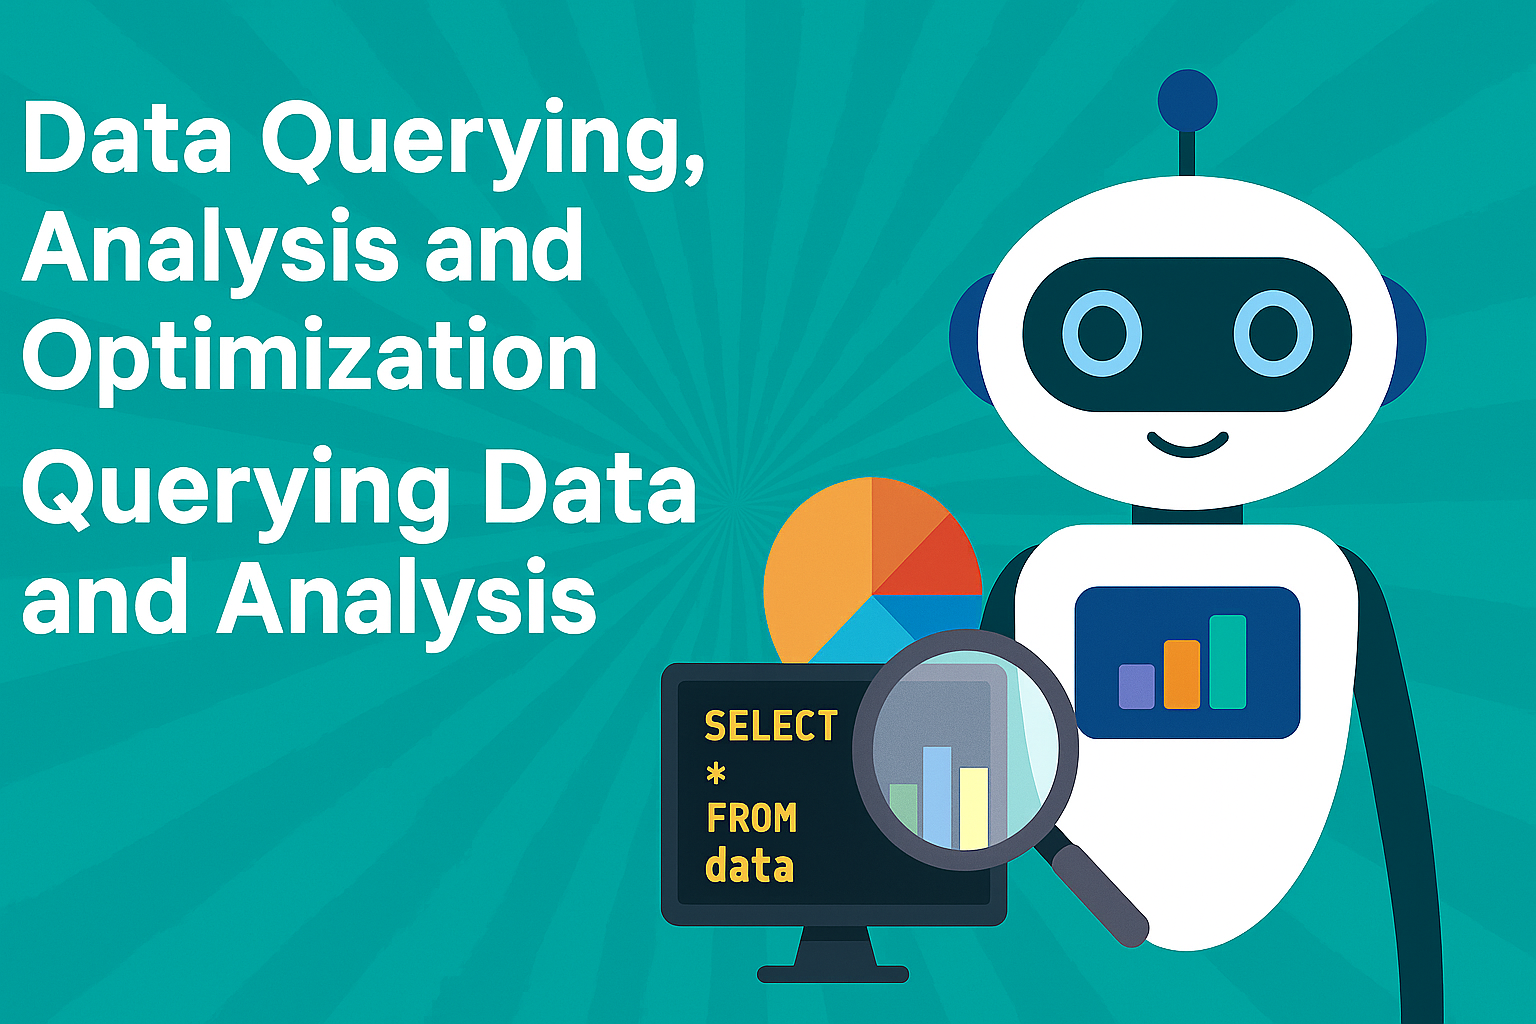

# 🗄️ Querying Data and Analysis with Generative AI

**Data querying and analysis are fundamental tasks for any data engineer.** Whether
you're fetching insights from large datasets, optimizing SQL queries, or interpreting
results, these tasks traditionally require domain expertise and manual effort. With
the advent of generative AI, data querying and analysis can be made significantly
more efficient and accessible, even for non-technical users.

In this series, we explore how generative AI can:
* Convert natural language questions into SQL queries
* Optimize SQL queries for performance  
* Interpret query results and provide insights
* Automate querying processes for efficiency

**Learning Objectives:**
- ✅ Convert natural language to SQL queries automatically
- ✅ Generate schema-aware SQL with table joins
- ✅ Interpret query results and extract meaningful insights
- ✅ Generate follow-up questions for deeper analysis
- ✅ Build AI-powered data analysis workflows

In [ ]:
# =====================================================
# 🛠️ SETUP AND IMPORTS
# =====================================================

from openai import OpenAI
import pandas as pd
import json
import numpy as np
from pprint import pprint
from google.colab import userdata

api_key=userdata.get('OPENAI_API_KEY')

# Set up our AI client securely
client = OpenAI(api_key=api_key)

def clean(dict_variable):
    return next(iter(dict_variable.values()))

print("✅ Environment ready for data querying and analysis!")


# =====================================================
# 🔄 CONVERTING NATURAL LANGUAGE TO SQL
# =====================================================


## 1. Converting Natural Language Queries to SQL

Generative AI can seamlessly convert human-readable queries into structured SQL
statements. Traditionally, a manager might ask:

*"Who was the top customer by revenue last month?"*

A data engineer would have to examine the schema, write a SQL query, execute it,
and return the results. Using generative AI, this process can be automated.

In [ ]:
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are a SQL expert. Convert English queries to SQL and output in JSON form."},
        {"role": "user", "content": "Find top 5 customers by revenue."}
    ],
    response_format={"type": "json_object"}
)

print(response.choices[0].message.content)

# =====================================================
# 🗺️ SCHEMA-AWARE SQL GENERATION
# =====================================================


## Schema-Aware SQL Generation

When multiple tables are involved, specifying the schema ensures that AI generates
an accurate query.

In [ ]:
schema = """

sales
order_id
customer_id
sales

customer
customer_code
customer_name

"""

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "You are a SQL expert. Convert English queries to SQL and output in JSON form"},
        {"role": "user", "content": "Find top 5 customers (customer names) by sales. The schema of this database is: {}".format(schema)}
    ],
    response_format={"type": "json_object"}
)

print(response.choices[0].message.content)

# =====================================================
# 📊 QUERY RESULT INTERPRETATION
# =====================================================


## 2. Query Result Interpretation

Generating SQL queries is just one part of the workflow. The next step is interpreting
query results to extract meaningful insights. Generative AI can analyze raw output
and provide a human-readable summary.

In [ ]:
query_result = """
| product_category | total_sales |
|-------------------|-------------|
| Electronics      | 1500000     |
| Clothing         | 980000      |
| Home & Garden    | 750000      |
| Books            | 320000      |
| Toys             | 280000      |
"""

prompt = f"Interpret the following query result and provide insights. Here's the result:\n{query_result}"

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": prompt}]
)

print(response.choices[0].message.content)

# =====================================================
# 💡 GENERATING INSIGHTS FROM QUERY RESULTS
# =====================================================


## 3. Generating Insights from Query Results

Once we have retrieved the query results, the next logical step is analyzing them
to derive meaningful insights. But what if we could also generate follow-up questions
to guide deeper exploration? Generative AI can not only interpret the data but also
suggest relevant queries that help drive better decision-making.

This ability to generate context-aware follow-up questions enhances business
intelligence, allowing analysts to dive deeper into trends and patterns without
having to manually brainstorm additional queries

In [ ]:
prompt = """Based on the following query result, suggest 3 relevant follow-up questions for further analysis:
{
  "category": ["Electronics", "Clothing", "Books"],
  "total_sales": [500000, 300000, 100000]
}"""

response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": prompt}]
)

print(response.choices[0].message.content)

Based on the query result you provided, here are three relevant follow-up questions for further analysis:

1. **What are the trends in sales over time for each category?**  
   This question would help in understanding whether the sales in Electronics, Clothing, and Books are increasing or decreasing, and if there are specific seasons or events that impact these trends.

2. **How do the demographics of customers vary across the different categories?**  
   Analyzing customer demographics (age, gender, location, etc.) for each category can provide insights into target markets and help tailor marketing strategies for each product category.

3. **What are the top-selling products within each category, and what factors contribute to their sales performance?**  
   Identifying the specific products that drive sales in each category can help understand consumer preferences and inform inventory and marketing decisions. Additionally, examining factors like pricing, promotions, and reviews coul

# =====================================================
# 🎯 CONCLUSION
# =====================================================


Generative AI is revolutionizing the way data engineers query and analyze data.
By leveraging AI to generate, optimize, and interpret SQL queries, we can significantly
improve efficiency, reduce errors, and make data analysis more accessible.

Generative AI is not just a tool for developers — it's a game-changer for data
engineering as a whole.